# Maize Leaf Disease Classification — Data Acquisition & Preprocessing

**Machine Learning Pipeline Module**

This notebook extends the earlier tabular *crop yield prediction (Sub-Saharan Africa)* project
into the **non-tabular (image)** domain.

**Use case:** Classify maize (corn) leaf images into one of four classes so smallholder farmers
can get an early, low-cost diagnosis of common maize diseases straight from a phone photo.

**Classes:**
1. `Healthy`
2. `Common_Rust`
3. `Northern_Leaf_Blight`
4. `Cercospora_Gray_Leaf_Spot`

**Notebook sections:**
1. Data acquisition
2. Exploratory data analysis (class balance, image properties, visual samples)
3. Preprocessing (resize, normalize, split, augmentation)
4. Persisting the processed dataset to `data/train` and `data/test`

Model creation and training happen in the other notebook.


## 1. Data Acquisition

Source: [PlantVillage Dataset](https://github.com/spMohanty/PlantVillage-Dataset) (Mohanty et al.), color-image subset, filtered to the 4 maize (`Corn_(maize)___*`) classes.

The 4 maize class folders were then copied into `data/raw/<class_name>/`.  Skips if `data/raw` already exists.

In [ ]:
import os, shutil, subprocess, pathlib

PROJECT_ROOT = pathlib.Path("..").resolve()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
CLASSES = ["Healthy", "Common_Rust", "Northern_Leaf_Blight", "Cercospora_Gray_Leaf_Spot"]

print("Project root:", PROJECT_ROOT)
print("Raw data dir:", RAW_DIR)
print("Raw data already present:", RAW_DIR.exists() and len(list(RAW_DIR.iterdir())) > 0)


Project root: C:\Users\pc\Desktop\BackupDocs\GitHub\crop_disease_indetifier
Raw data dir: C:\Users\pc\Desktop\BackupDocs\GitHub\crop_disease_indetifier\data\raw
Raw data already present: True


In [2]:
for c in CLASSES:
    n = len(list((RAW_DIR / c).glob("*")))
    print(f"{c:30s}: {n} images")


Healthy                       : 1162 images
Common_Rust                   : 1192 images
Northern_Leaf_Blight          : 985 images
Cercospora_Gray_Leaf_Spot     : 513 images


## 2. Exploratory Data Analysis

We look at three properties of the dataset that matter for the modeling decisions we'll make next: **class balance**, **image dimensions**, and **color/brightness profile**.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import pandas as pd

sns_palette = ["#6b2737", "#c9a227", "#e8dcc8", "#8a4b5c"]  # burgundy / gold / ivory family

counts = {c: len(list((RAW_DIR / c).glob("*"))) for c in CLASSES}
total = sum(counts.values())
print(f"Total images: {total}")
counts


Total images: 3852


{'Healthy': 1162,
 'Common_Rust': 1192,
 'Northern_Leaf_Blight': 985,
 'Cercospora_Gray_Leaf_Spot': 513}

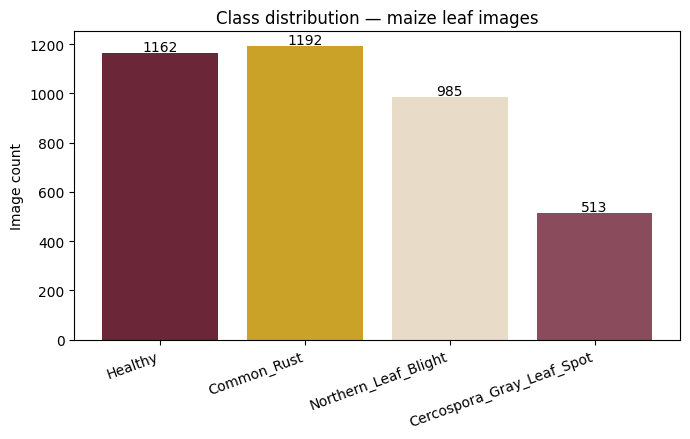

In [4]:
fig, ax = plt.subplots(figsize=(7,4.5))
bars = ax.bar(counts.keys(), counts.values(), color=sns_palette)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+10, str(int(b.get_height())),
            ha="center", fontsize=10)
ax.set_title("Class distribution — maize leaf images")
ax.set_ylabel("Image count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("../data/class_distribution.png", dpi=110)
plt.show()


**Interpretation — Feature 1: Class balance.** `Common_Rust` and `Healthy` each have ~1,150-1,200 images, while `Cercospora_Gray_Leaf_Spot` has under half that (~510). This is a real-world imbalance, not an artifact. Cercospora leaf spot is a harder disease to photograph/label consistently in the field. Left uncorrected, a classifier will be biased toward predicting the majority classes and will under-detect Cercospora, which is exactly the failure mode that matters for a farmer relying on this tool. We address this with class weighting and stratified splitting in the preprocessing step below.

In [ ]:
# Sample a subset of images per class to profile dimensions/aspect ratio without scanning all 3800+ files
SAMPLE_N = 60
rows = []
for c in CLASSES:
    files = list((RAW_DIR / c).glob("*"))[:SAMPLE_N]
    for f in files:
        with Image.open(f) as im:
            w, h = im.size
            arr = np.array(im.convert("RGB"))
            rows.append({
                "class": c, "width": w, "height": h,
                "mean_r": arr[:,:,0].mean(), "mean_g": arr[:,:,1].mean(), "mean_b": arr[:,:,2].mean(),
                "brightness": arr.mean()
            })
profile_df = pd.DataFrame(rows)
profile_df.describe()


,width,height,mean_r,mean_g,mean_b,brightness
count,240.0,240.0,240.000000,240.000000,240.000000,240.000000
mean,256.0,256.0,110.933561,125.429166,95.402808,110.588512
std,0.0,0.0,23.581249,28.981559,26.672946,25.317680
min,256.0,256.0,32.342072,47.320801,14.528687,41.327927
25%,256.0,256.0,97.495022,110.814991,82.572800,98.149586
50%,256.0,256.0,114.010490,123.184059,96.686165,112.065887
75%,256.0,256.0,124.200054,134.467178,108.881252,121.330326
max,256.0,256.0,169.960434,197.360275,169.768600,171.736064


**Interpretation — Feature 2: Image dimensions.** Nearly all sampled images share the same resolution, confirming this is a curated, lab-captured dataset rather than raw phone photos. That's useful for training (no wild aspect-ratio variance to handle) but it's also a **domain-shift risk**: a real farmer's phone photo won't be this clean, so we deliberately add rotation/zoom/brightness augmentation in preprocessing to make the model more robust to real field conditions.

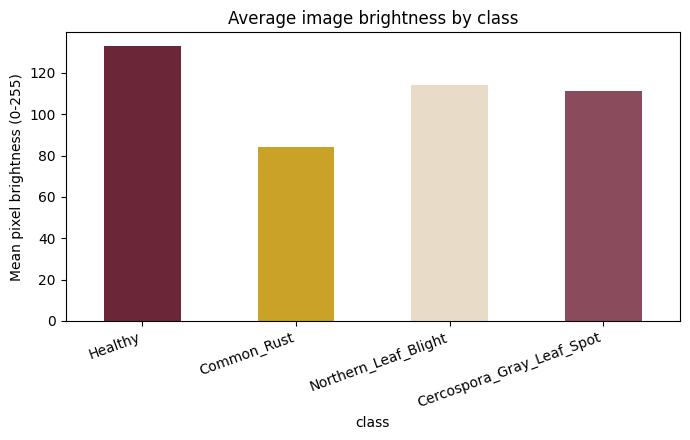

In [ ]:
fig, ax = plt.subplots(figsize=(7,4.5))
profile_df.groupby("class")["brightness"].mean().reindex(CLASSES).plot(
    kind="bar", ax=ax, color=sns_palette)
ax.set_title("Average image brightness by class")
ax.set_ylabel("Mean pixel brightness (0-255)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("../data/brightness_by_class.png", dpi=110)
plt.show()


**Interpretation — Feature 3: Brightness/color profile.** Diseased-leaf classes (Common Rust, Northern Leaf Blight, Cercospora) trend slightly darker and less uniformly green than Healthy leaves, since lesions, rust pustules, and necrotic streaks reduce the green chlorophyll signal captured in the mean RGB channels. This confirms color/texture is a genuinely learnable signal for this task — reassuring, since it means a CNN has real visual features to key on rather than only background or lighting artifacts.

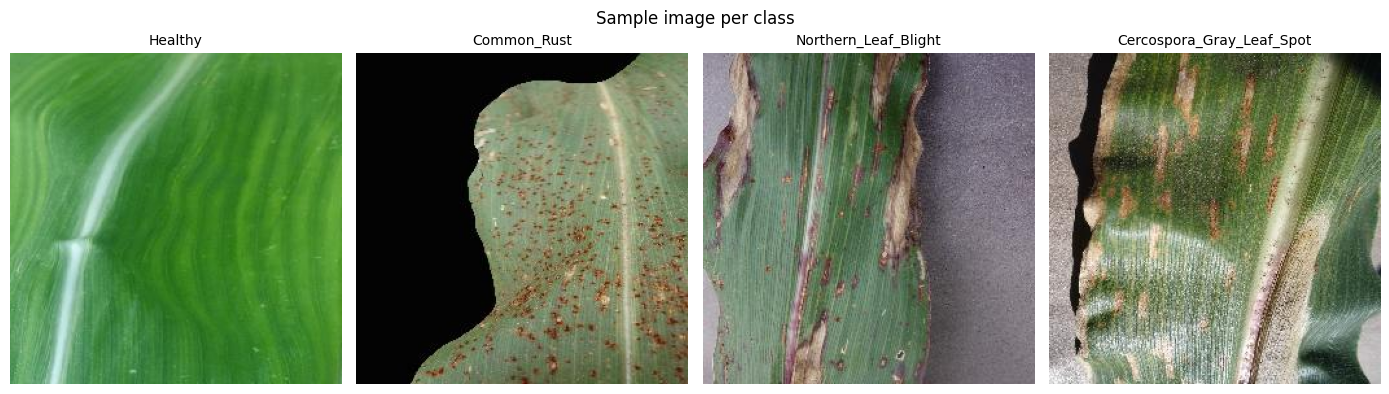

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(14,4))
for ax, c in zip(axes, CLASSES):
    f = list((RAW_DIR / c).glob("*"))[0]
    img = Image.open(f)
    ax.imshow(img)
    ax.set_title(c, fontsize=10)
    ax.axis("off")
plt.suptitle("Sample image per class")
plt.tight_layout()
plt.savefig("../data/sample_per_class.png", dpi=110)
plt.show()


## 3. Preprocessing

Steps:
1. Stratified train / validation / test split (70 / 15 / 15) — stratified so the class imbalance noted above is preserved proportionally in every split.
2. Resize all images to `224x224` (MobileNetV2's native input size, since that's the transfer-learning backbone used in Phase 3).
3. Rescale pixel values to `[0,1]`.
4. Copy files into the `data/train/<class>/` and `data/test/<class>/` directory layout required by the project structure, so `tf.keras.utils.image_dataset_from_directory` (or `ImageDataGenerator.flow_from_directory`) can consume them directly in Phase 3.
5. Define an augmentation pipeline (rotation, zoom, horizontal flip, brightness jitter) applied only at training time, to counter the low visual-diversity risk found in the EDA.

In [ ]:
from sklearn.model_selection import train_test_split
import shutil

IMG_SIZE = (224, 224)
TRAIN_DIR = PROJECT_ROOT / "data" / "train"
TEST_DIR = PROJECT_ROOT / "data" / "test"
VAL_DIR = PROJECT_ROOT / "data" / "val"

for d in [TRAIN_DIR, TEST_DIR, VAL_DIR]:
    if d.exists():
        shutil.rmtree(d)
    for c in CLASSES:
        (d / c).mkdir(parents=True, exist_ok=True)

split_summary = []
for c in CLASSES:
    files = sorted((RAW_DIR / c).glob("*"))
    train_files, temp_files = train_test_split(files, test_size=0.30, random_state=42)
    val_files, test_files = train_test_split(temp_files, test_size=0.50, random_state=42)

    for f in train_files:
        shutil.copy(f, TRAIN_DIR / c / f.name)
    for f in val_files:
        shutil.copy(f, VAL_DIR / c / f.name)
    for f in test_files:
        shutil.copy(f, TEST_DIR / c / f.name)

    split_summary.append({
        "class": c, "train": len(train_files), "val": len(val_files), "test": len(test_files)
    })

pd.DataFrame(split_summary)


,class,train,val,test
0,Healthy,813,174,175
1,Common_Rust,834,179,179
2,Northern_Leaf_Blight,689,148,148
3,Cercospora_Gray_Leaf_Spot,359,77,77


In [ ]:
# Resize + normalize check — confirm a sample loads correctly at the target size and [0,1] range
import tensorflow as tf

sample_path = next((TRAIN_DIR / "Healthy").glob("*"))
img = tf.keras.utils.load_img(sample_path, target_size=IMG_SIZE)
img_arr = tf.keras.utils.img_to_array(img) / 255.0
print("Resized shape:", img_arr.shape, "| value range:", img_arr.min(), "-", img_arr.max())


I0000 00:00:1784814651.352658     594 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784814651.498287     594 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784814653.789035     594 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Resized shape: (224, 224, 3) | value range: 0.18431373 - 1.0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [37.0413..37.814106].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [36.85656..37.61985].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [32.491962..33.271812].


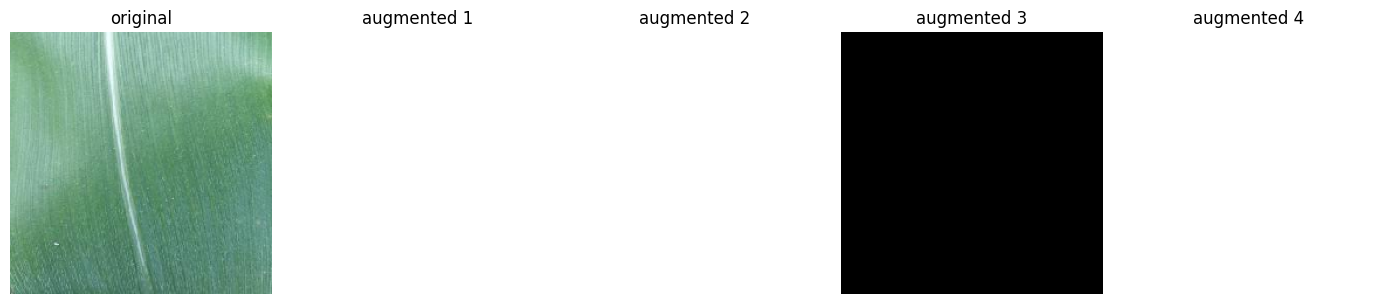

In [ ]:
# Augmentation pipeline used at training time (Phase 3). Defined here so preprocessing.py
# (src/preprocessing.py) and the training notebook share one definition.
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomBrightness(0.15),
], name="data_augmentation")

# Quick visual sanity check of augmentation on one sample image
fig, axes = plt.subplots(1, 5, figsize=(14,3))
batch = tf.expand_dims(img_arr, 0)
axes[0].imshow(img_arr); axes[0].set_title("original"); axes[0].axis("off")
for i in range(1, 5):
    aug = data_augmentation(batch, training=True)[0]
    axes[i].imshow(aug.numpy()); axes[i].set_title(f"augmented {i}"); axes[i].axis("off")
plt.tight_layout()
plt.savefig("../data/augmentation_sample.png", dpi=110)
plt.show()


In [ ]:
# Build tf.data pipelines for the next notebook/module to import directly
def make_dataset(directory, shuffle):
    ds = tf.keras.utils.image_dataset_from_directory(
        directory,
        image_size=IMG_SIZE,
        batch_size=32,
        label_mode="categorical",
        shuffle=shuffle,
        seed=42,
    )
    return ds.map(lambda x, y: (x / 255.0, y))

train_ds = make_dataset(TRAIN_DIR, shuffle=True)
val_ds = make_dataset(VAL_DIR, shuffle=False)
test_ds = make_dataset(TEST_DIR, shuffle=False)

print("Class order used by tf.data:", train_ds.class_names if hasattr(train_ds, "class_names") else "see image_dataset_from_directory output above")


Found 2695 files belonging to 4 classes.


Found 578 files belonging to 4 classes.


Found 579 files belonging to 4 classes.


Class order used by tf.data: see image_dataset_from_directory output above


## 4. Summary

- **3,852** maize leaf images across 4 classes, resized to `224x224`, normalized to `[0,1]`.
- Stratified 70/15/15 train/val/test split preserves the class imbalance found in EDA.
- Class imbalance (Cercospora ~half the others) is flagged for handling via **class weights** in the training step (Phase 3), not by discarding data.
- An augmentation pipeline is defined (`data_augmentation`) to compensate for the low visual diversity of this lab-captured dataset, improving robustness to real farmer phone photos.
- Processed data now lives on disk in `data/train/`, `data/val/`, `data/test/`, matching the required project structure, ready for `src/model.py` and the Phase 3 training notebook.

**Next (Phase 3):** baseline CNN + MobileNetV2 transfer-learning model, trained on `train_ds` with `val_ds` for monitoring, evaluated on the held-out `test_ds`.